# LIVE CODING 1


Este notebook está pensado para acompañar una demo breve en clase.

## Objetivo
Mostrar de forma simple:
- cuándo usar **ML tradicional**
- cuándo usar **Deep Learning**
- qué arquitectura elegir según el tipo de dato

## Ruta de la demo
1. Relación entre IA, ML y DL  
2. Datos estructurados vs no estructurados  
3. Ejemplos de arquitecturas: DNN, CNN, RNN y Transformers  
4. Caso práctico corto con imágenes (MNIST)  


## 1. IA, Machine Learning y Deep Learning

Podemos pensarlo así:

- **Inteligencia Artificial (IA)**: campo amplio
- **Machine Learning (ML)**: modelos que aprenden patrones desde datos
- **Deep Learning (DL)**: una rama de ML basada en redes neuronales profundas

En clase puedes decir algo como:

> No todo ML es Deep Learning, pero todo Deep Learning pertenece al mundo de ML.


In [1]:
# Diagrama simple en texto
print("Inteligencia Artificial")
print("   └── Machine Learning")
print("         └── Deep Learning")

Inteligencia Artificial
   └── Machine Learning
         └── Deep Learning


## 2. Tipo de dato y arquitectura sugerida

La decisión depende mucho del tipo de dato que tengamos.


In [2]:
import pandas as pd

tabla = pd.DataFrame({
    "Tipo de dato": ["Tabular", "Imagen", "Texto", "Audio / secuencia"],
    "Ejemplo": ["Edad, ingreso, gasto", "Fotos, rayos X", "Comentarios, correos", "Voz, series temporales"],
    "Arquitectura típica": ["DNN o ML tradicional", "CNN", "Transformers", "RNN/LSTM o Transformers"]
})

tabla

,Tipo de dato,Ejemplo,Arquitectura típica
0,Tabular,"Edad, ingreso, gasto",DNN o ML tradicional
1,Imagen,"Fotos, rayos X",CNN
2,Texto,"Comentarios, correos",Transformers
3,Audio / secuencia,"Voz, series temporales",RNN/LSTM o Transformers


## 3. Ejemplo rápido de dato estructurado

Cuando los datos están en forma de tabla, muchas veces un modelo clásico funciona muy bien.
Aquí solo armaremos una mini tabla de ejemplo para reforzar la idea.


In [3]:
clientes = pd.DataFrame({
    "edad": [22, 35, 41, 28, 50],
    "ingreso": [450000, 1200000, 980000, 600000, 1500000],
    "gasto_mensual": [120000, 450000, 300000, 180000, 500000]
})

clientes

,edad,ingreso,gasto_mensual
0,22,450000,120000
1,35,1200000,450000
2,41,980000,300000
3,28,600000,180000
4,50,1500000,500000


### Idea para comentar en vivo

- Si tengo variables como edad, ingreso y gasto, probablemente puedo partir con:
  - regresión logística
  - árbol de decisión
  - random forest
  - una DNN simple

Es decir, **no siempre necesito Deep Learning complejo**.


## 4. Caso práctico corto: imágenes con MNIST

Ahora cambiamos a un dato **no estructurado**: imágenes.

MNIST contiene imágenes de dígitos escritos a mano.  
Este tipo de dato ya no es una tabla tradicional, por eso una **CNN** suele ser una mejor elección.


In [4]:
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist

(X_train, y_train), (X_test, y_test) = mnist.load_data()

print("Forma X_train:", X_train.shape)
print("Forma y_train:", y_train.shape)
print("Forma X_test:", X_test.shape)

Forma X_train: (60000, 28, 28)
Forma y_train: (60000,)
Forma X_test: (10000, 28, 28)


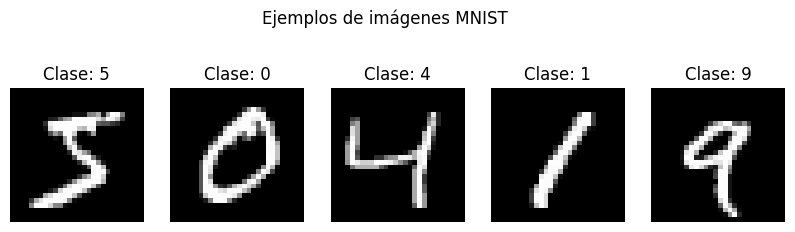

In [5]:
fig, axes = plt.subplots(1, 5, figsize=(10, 3))

for i, ax in enumerate(axes):
    ax.imshow(X_train[i], cmap="gray")
    ax.set_title(f"Clase: {y_train[i]}")
    ax.axis("off")

plt.suptitle("Ejemplos de imágenes MNIST")
plt.show()

### Comentario para clase

Aquí puedes decir:

> Como la entrada es una imagen, ya no basta pensar solo en columnas.  
> Necesitamos una red que respete la estructura espacial de los píxeles.  
> Ahí aparece la CNN.


## 5. Preparación simple de datos

Normalizamos y agregamos la dimensión del canal.


In [6]:
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

# Agregamos canal: (28, 28) -> (28, 28, 1)
X_train = X_train[..., None]
X_test = X_test[..., None]

print("Nueva forma X_train:", X_train.shape)
print("Nueva forma X_test:", X_test.shape)

Nueva forma X_train: (60000, 28, 28, 1)
Nueva forma X_test: (10000, 28, 28, 1)


## 6. CNN muy corta

No buscamos el mejor modelo del mundo.  
Buscamos una red pequeña que sirva para explicar la lógica:

- convolución
- activación ReLU
- pooling
- flatten
- capa densa de salida


In [7]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

model = Sequential([
    Conv2D(16, kernel_size=(3, 3), activation="relu", input_shape=(28, 28, 1)),
    MaxPooling2D(pool_size=(2, 2)),
    Flatten(),
    Dense(10, activation="softmax")
])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

d:\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2704)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │        27,050 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 27,210 (106.29 KB)

 Trainable params: 27,210 (106.29 KB)

 Non-trainable params: 0 (0.00 B)

## 7. Entrenamiento rápido

Usamos solo 1 época para que la demo sea ligera.


In [8]:
history = model.fit(
    X_train, y_train,
    validation_split=0.1,
    epochs=1,
    batch_size=128,
    verbose=1
)

422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.8899 - loss: 0.4063 - val_accuracy: 0.9603 - val_loss: 0.1514


In [9]:
loss, acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Accuracy en test: {acc:.4f}")

Accuracy en test: 0.9489


## 8. Predicciones

Aquí mostramos algunas imágenes y la clase predicha.


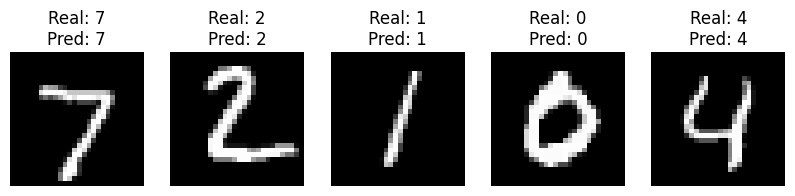

In [10]:
pred = model.predict(X_test[:5], verbose=0).argmax(axis=1)

fig, axes = plt.subplots(1, 5, figsize=(10, 3))
for i, ax in enumerate(axes):
    ax.imshow(X_test[i].squeeze(), cmap="gray")
    ax.set_title(f"Real: {y_test[i]}\nPred: {pred[i]}")
    ax.axis("off")
plt.show()

## 9. Cierre de la demo

### Idea central
La arquitectura no se elige al azar.

- **Datos tabulares** → modelos clásicos o DNN simples
- **Imágenes** → CNN
- **Texto** → Transformers
- **Secuencias** → RNN/LSTM o Transformers

### Frase final para clase
> El valor del Deep Learning no está solo en entrenar redes, sino en elegir la arquitectura adecuada según el problema y el tipo de datos.
